In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

import camb
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pysm3
import pysm3.units as u
import pandas as pd
from pathlib import Path
from astropy.table import Table, vstack
from tqdm.auto import tqdm
from pathlib import Path

/home/barbarantares/miniconda3/envs/cosmo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.rcParams['font.family']       = 'serif'
mpl.rcParams['font.serif']        = ['DejaVu Serif', 'Times New Roman', 'serif']
mpl.rcParams['mathtext.fontset']  = 'dejavuserif'   
mpl.rcParams['text.usetex']       = False            

mpl.rcParams['font.size']         = 14
mpl.rcParams['axes.titlesize']    = 15
mpl.rcParams['axes.labelsize']    = 14
mpl.rcParams['xtick.labelsize']   = 12
mpl.rcParams['ytick.labelsize']   = 12
mpl.rcParams['legend.fontsize']   = 12
mpl.rcParams['legend.title_fontsize'] = 13


mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['savefig.dpi']       = 600         
mpl.rcParams['savefig.bbox']      = 'tight'
mpl.rcParams['savefig.format']    = 'pdf'       

mpl.rcParams['axes.spines.top']   = True
mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.edgecolor']    = 'black'
mpl.rcParams['axes.linewidth']    = 1.2  


N_colores = 8                                      
cmap      = mpl.colormaps['rainbow']               
colores   = [cmap(i / (N_colores - 1)) for i in range(N_colores)]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colores)

mpl.rcParams['axes.grid']         = True
mpl.rcParams['grid.color']        = '0.85'
mpl.rcParams['grid.linestyle']    = '--'
mpl.rcParams['grid.linewidth']    = 0.6
mpl.rcParams['grid.alpha']        = 0.7

mpl.rcParams['xtick.direction']   = 'in'
mpl.rcParams['ytick.direction']   = 'in'
mpl.rcParams['xtick.major.size']  = 5
mpl.rcParams['ytick.major.size']  = 5
mpl.rcParams['xtick.minor.size']  = 3
mpl.rcParams['ytick.minor.size']  = 3
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

mpl.rcParams['lines.linewidth']   = 2.0
mpl.rcParams['lines.markersize']  = 6

mpl.rcParams['legend.frameon']    = True
mpl.rcParams['legend.framealpha'] = 0.85
mpl.rcParams['legend.edgecolor']  = '0.8'
mpl.rcParams['legend.fancybox']   = False

mpl.rcParams['image.cmap']        = 'rainbow' 

Pixeles válidos: 42,399,813 / 50,331,648


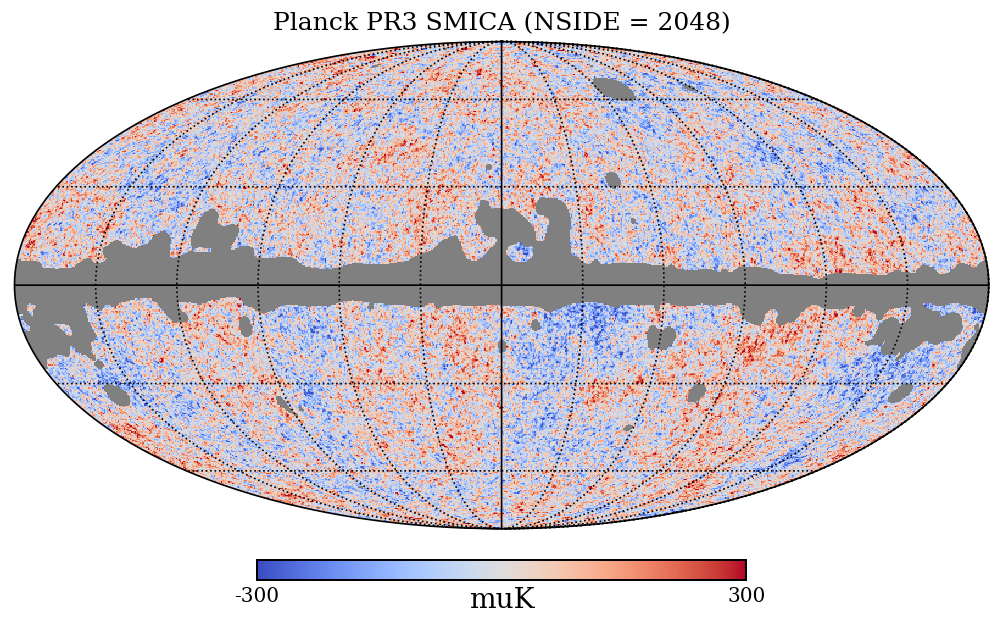

In [8]:
NSIDE = 2048

FITS_SMICA = '/home/barbarantares/Documentos/CMB/COM_CMB_IQU-smica_2048_R3.00_full.fits'

mapa_smica  = hp.read_map(FITS_SMICA, field=0, nest=True)
mask_smica = hp.read_map(FITS_SMICA, field=3, nest=True)

mapa_smica  = hp.reorder(mapa_smica,  n2r=True)
mask_smica = hp.reorder(mask_smica, n2r=True)

mapa_smica = mapa_smica * 1e6

BAD_DATA = -1.6375e30

mapa_smica[mask_smica == 0] = hp.UNSEEN
print(f"Pixeles válidos: {(mapa_smica != hp.UNSEEN).sum():,} / {len(mapa_smica):,}")

hp.mollview(mapa_smica, title='Planck PR3 SMICA (NSIDE = 2048)', cmap='coolwarm', unit='muK', min=-300, max=300)
hp.graticule()
plt.show()

In [2]:
from astropy.io import fits

FITS_SMICA = '/home/barbarantares/Documentos/CMB/COM_CMB_IQU-smica_2048_R3.00_full.fits'

header_smica = fits.getheader(FITS_SMICA, 1)
header_smica

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                   40 / width of table in bytes                        
NAXIS2  =             50331648 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   10 / number of fields in each row                   
COMMENT  -------------------------------------------------------------          
COMMENT  Products from SMICA component separation method                        
COMMENT  -------------------------------------------------------------          
COMMENT  Further details in the Planck Legacy Archive and Explanatory Supplement
COMMENT  http://www.cosmos.e

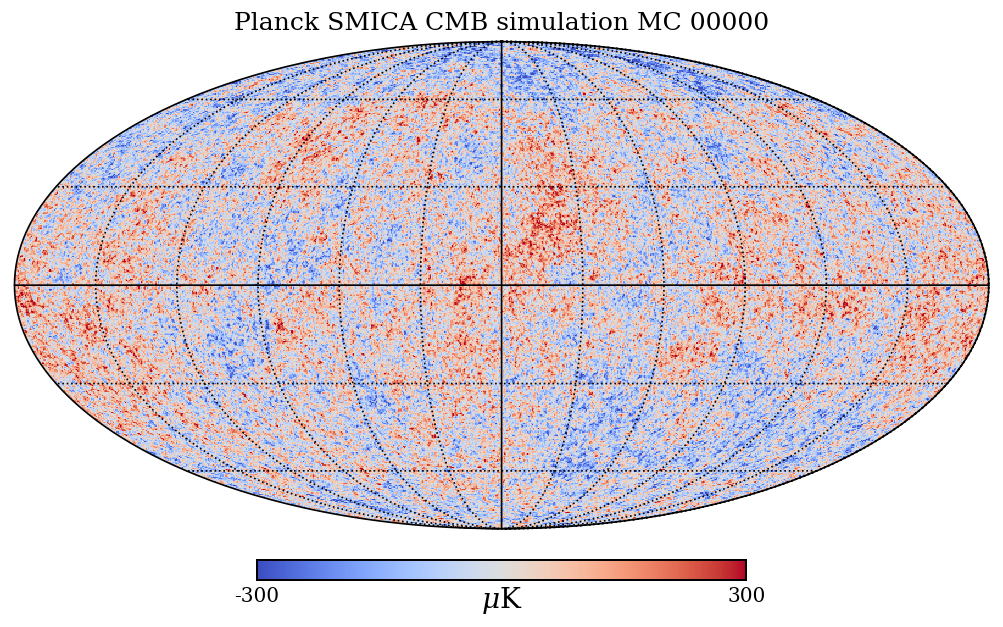

In [35]:
NSIDE = 2048

FITS_SIM = "/home/barbarantares/Documentos/SESSION/dx12_v3_smica_cmb_mc_00000_raw.fits"

mapa_sim = hp.read_map(FITS_SIM,field=0,nest=True)

mapa_sim = hp.reorder(mapa_sim,n2r=True)
mapa_sim = mapa_sim * 1e6

hp.mollview(mapa_sim, title="Planck SMICA CMB simulation MC 00000", cmap="coolwarm", unit=r"$\mu$K", min=-300, max=300)

hp.graticule()
plt.show()

Pixeles válidos: 42,399,813 / 50,331,648


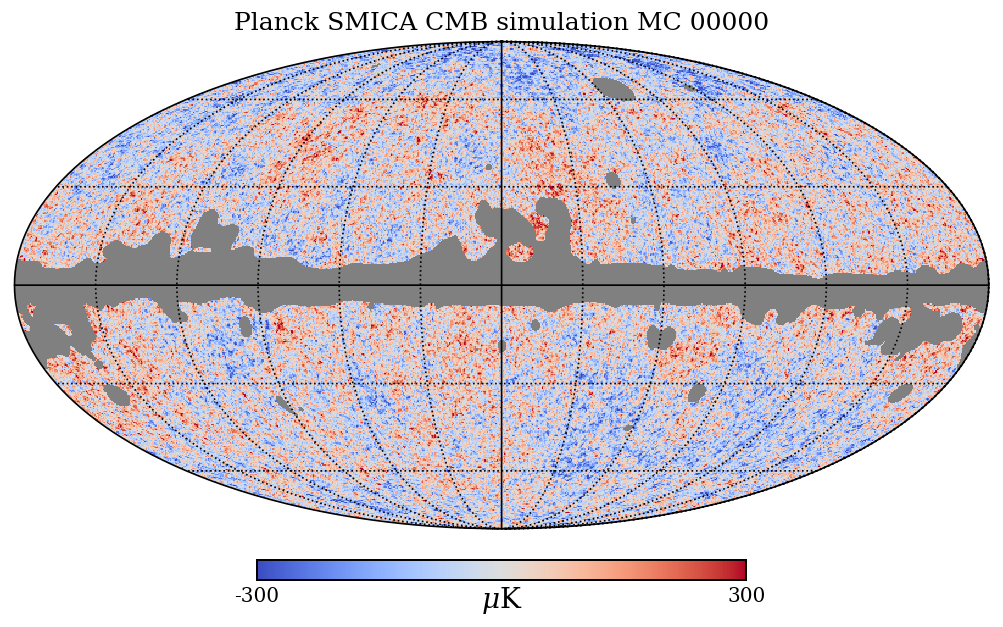

In [38]:
NSIDE = 2048

FITS_SIM = "/home/barbarantares/Documentos/SESSION/dx12_v3_smica_cmb_mc_00000_raw.fits"
FITS_SMICA = "/home/barbarantares/Documentos/CMB/COM_CMB_IQU-smica_2048_R3.00_full.fits"

mapa_smica = hp.read_map(FITS_SIM,field=0,nest=True)
mapa_smica = hp.reorder(mapa_smica,n2r=True)
mapa_smica = mapa_smica * 1e6

mask_smica = hp.read_map(FITS_SMICA,field=3,nest=True)
mask_smica = hp.reorder(mask_smica,n2r=True)

mapa_smica[mask_smica == 0] = hp.UNSEEN

print(f"Pixeles válidos: {(mapa_smica != hp.UNSEEN).sum():,} / {len(mapa_smica):,}")

hp.mollview(
    mapa_smica,
    title="Planck SMICA CMB simulation MC 00000",
    cmap="coolwarm",
    unit=r"$\mu$K",
    min=-300,
    max=300
)

hp.graticule()
plt.savefig("/home/barbarantares/Documentos/SESSION/sim+mask.png", dpi=600, bbox_inches="tight")

plt.show()

In [16]:
cat = Table.read("/home/barbarantares/Documentos/CMB/2mrs_v240/catalog/2mrs_1175_done.fits")

print(f"Total de galaxias cargadas: {len(cat):,}")
print(cat.colnames)

k_c   = np.ma.asarray(cat["MKC"], dtype=float).filled(np.nan)
b_gal = np.ma.asarray(cat["GLAT"], dtype=float).filled(np.nan)
v_all = np.ma.asarray(cat["V"], dtype=float).filled(np.nan)

mask = ((k_c <= 11.254) & (np.abs(b_gal) > 10))
muestra = cat[mask]

print(f"Galaxias en la submuestra final: {len(muestra):,}")

Total de galaxias cargadas: 43,533
['TMID', 'RA', 'DEC', 'GLON', 'GLAT', 'MKC', 'MHC', 'MJC', 'MKTC', 'MHTC', 'MJTC', 'EKC', 'EHC', 'EJC', 'EKTC', 'EHTC', 'EJTC', 'EBV', 'RISO', 'RTOT', 'BA', 'FLAGS', 'TYPE', 'TYPESRC', 'V', 'EV', 'VCAT', 'VSRC', 'CATID']
Galaxias en la submuestra final: 20,860


In [17]:
def col_float(tabla, nombre):
    return np.ma.asarray(tabla[nombre], dtype=float).filled(np.nan)

ra = col_float(muestra, "RA")
dec = col_float(muestra, "DEC")
l = col_float(muestra, "GLON")
b = col_float(muestra, "GLAT")
k_c = col_float(muestra, "MKC")
h_c = col_float(muestra, "MHC")
j_c = col_float(muestra, "MJC")
e_bv = col_float(muestra, "EBV")
ba = col_float(muestra, "BA")
r_iso = col_float(muestra, "RISO")
v = col_float(muestra, "V")
e_v = col_float(muestra, "EV")

z = v / 299_792.458
d_Mpc = v / 70.0

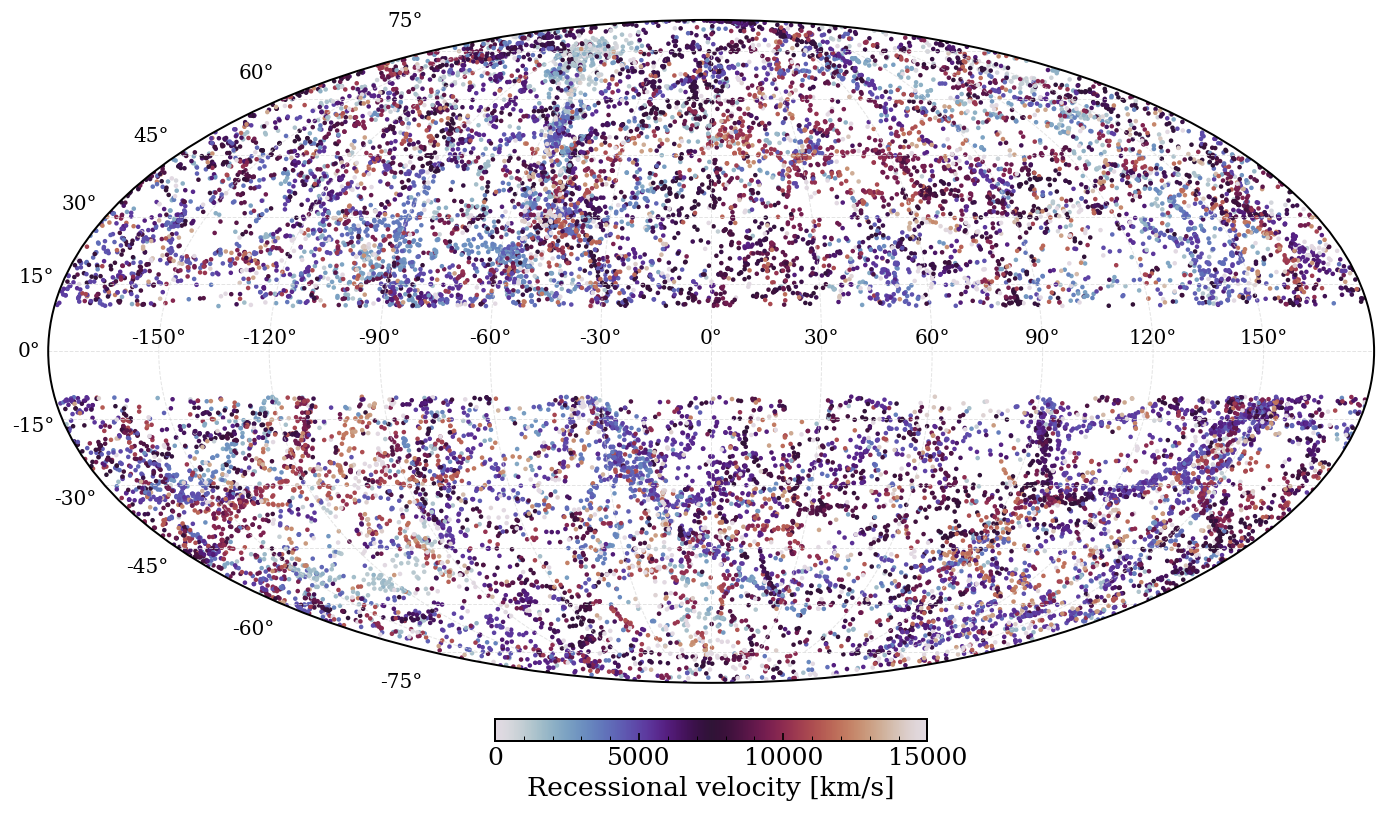

In [18]:
fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={'projection': 'mollweide'})

l_rad = np.deg2rad(l)
l_rad[l_rad > np.pi] -= 2 * np.pi
b_rad = np.deg2rad(b)

sc = ax.scatter(l_rad, b_rad, c=v, cmap='twilight', s=3, alpha=1, vmin=0, vmax=15000, rasterized=True)

cb = fig.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, fraction=0.03)
cb.ax.tick_params(labelsize=15)
cb.set_label('Recessional velocity [km/s]', fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
NSIDE = 2048
theta_gal = np.radians(90 - b)
phi_gal = np.radians(l)
pixeles_galaxias = hp.ang2pix(NSIDE, theta_gal, phi_gal)

mask_vals = mask_smica[pixeles_galaxias]
n_good = (mask_vals == 1).sum()
n_bad  = (mask_vals == 0).sum()

print(f"Galaxias en zona válida:", n_good)
print(f"Galaxias en máscara:", n_bad)

Galaxias en zona válida: 19893
Galaxias en máscara: 967


In [20]:
mask_gal_valida = (mask_vals == 1)

ra_v  = ra[mask_gal_valida]
dec_v = dec[mask_gal_valida]
l_v = l[mask_gal_valida]
b_v = b[mask_gal_valida]
v_v = v[mask_gal_valida]
theta_gal_v = theta_gal[mask_gal_valida]
phi_gal_v = phi_gal[mask_gal_valida]

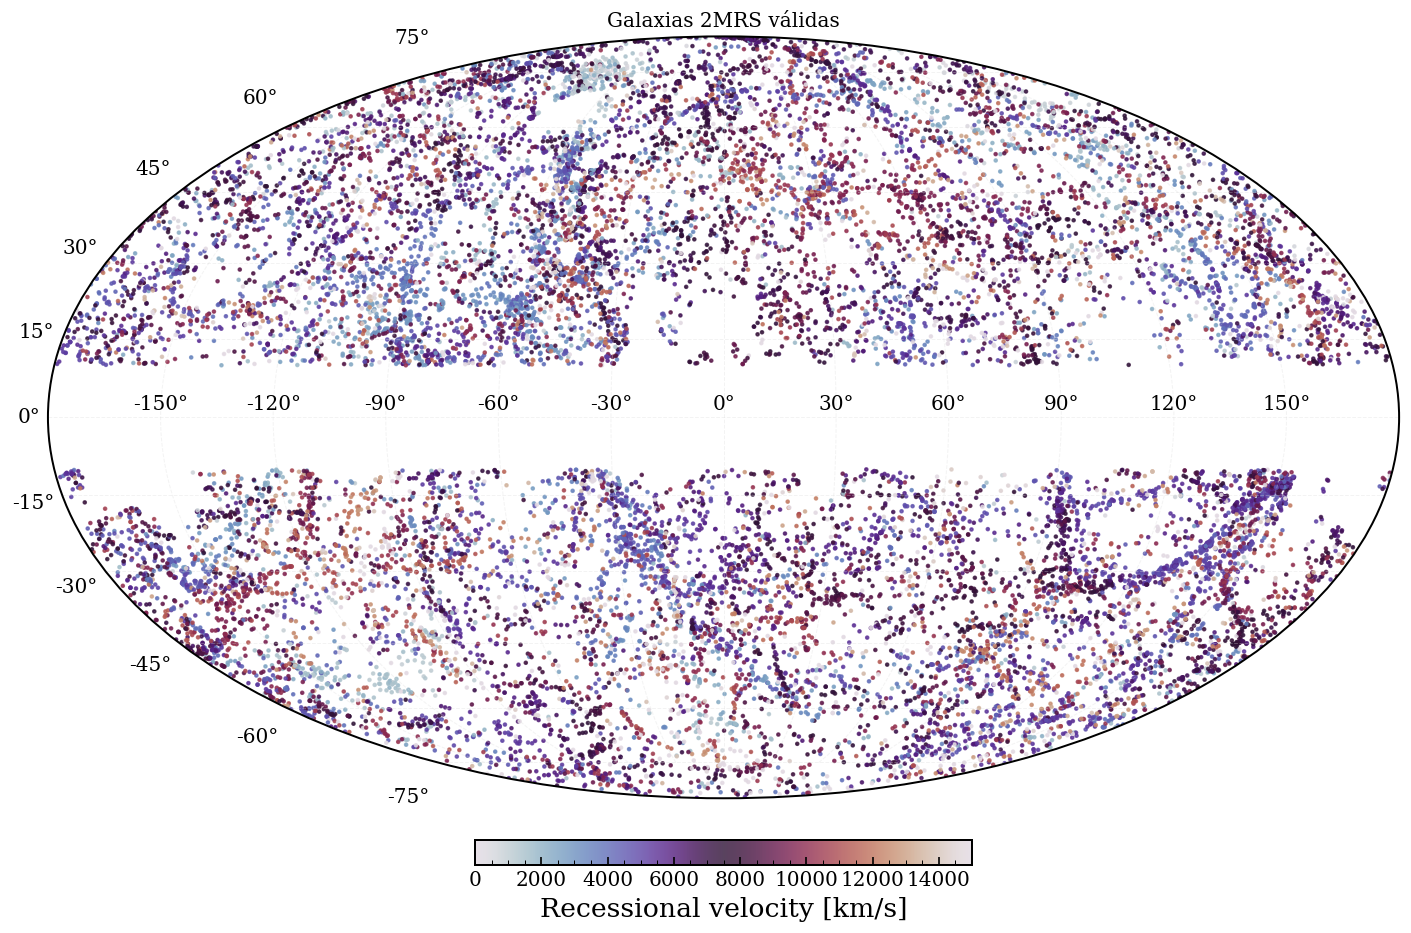

In [21]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': 'mollweide'})

map_img = hp.mollview(mapa_smica, cmap='coolwarm', min=-300, max=300, return_projected_map=True)
plt.close() 

ax.imshow(map_img, extent=[-np.pi, np.pi, -np.pi/2, np.pi/2], cmap='coolwarm', vmin=-300, vmax=300, aspect='auto', origin='upper')

l_rad = np.deg2rad(l_v)
l_rad[l_rad > np.pi] -= 2 * np.pi
b_rad = np.deg2rad(b_v)

sc = ax.scatter(l_rad, b_rad, c=v_v, cmap='twilight', s=3, alpha=0.8, vmin=0, vmax=15000, rasterized=True)

cb = fig.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, fraction=0.03)
cb.set_label('Recessional velocity [km/s]', fontsize=16)

ax.set_title('Galaxias 2MRS válidas', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

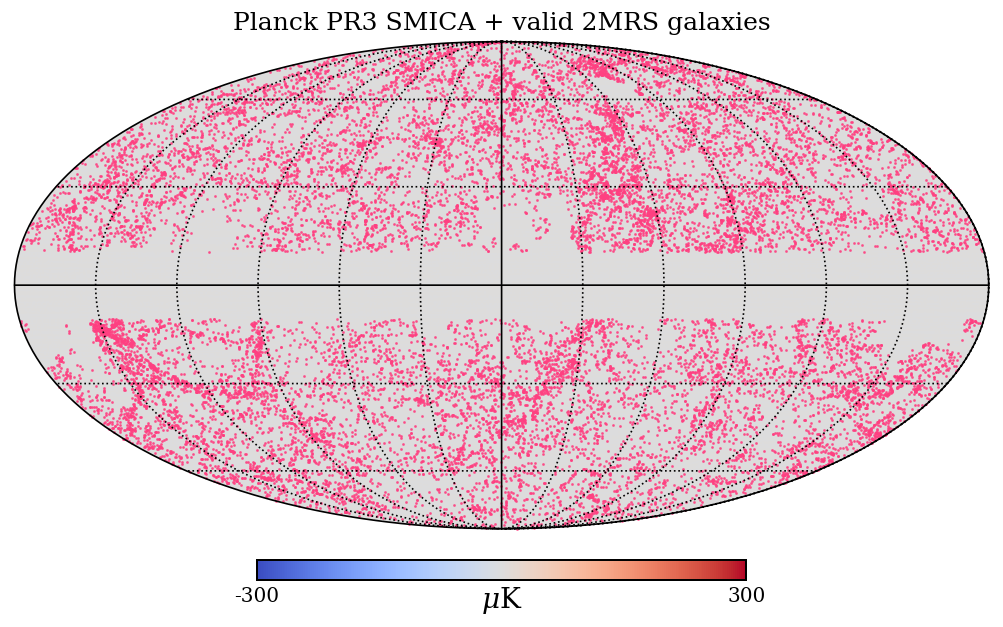

In [34]:
hp.mollview(mapa_smica, title='Planck PR3 SMICA + valid 2MRS galaxies', cmap='coolwarm', min=-300, max=300, unit=r'$\mu$K')
hp.projscatter(theta_gal_v, phi_gal_v, marker='.', s=2, color='#FF4081', alpha=0.8)
hp.graticule()
#plt.savefig("/home/barbarantares/Documentos/SESSION/galaxias+cmb_planck.png", dpi=600, bbox_inches="tight")

plt.show()

In [23]:
mask_A = (v_v > 0) & (v_v <= 5000)
mask_B = (v_v > 5000) & (v_v <= 7500)

theta_A = theta_gal_v[mask_A]
phi_A = phi_gal_v[mask_A]
v_A = v_v[mask_A]

theta_B = theta_gal_v[mask_B]
phi_B = phi_gal_v[mask_B]
v_B = v_v[mask_B]

print(f"Grupo A: {mask_A.sum():,} galaxias")
print(f"Grupo B: {mask_B.sum():,} galaxias")
print(f"Total: {mask_A.sum() + mask_B.sum():,} galaxias")

Grupo A: 6,203 galaxias
Grupo B: 5,588 galaxias
Total: 11,791 galaxias


In [25]:
n_puntos_A = len(theta_A)

r_inicial = 0.2
r_final = 30.2
ancho_anillo = 0.5

bordes_radiales = np.arange(r_inicial,r_final + ancho_anillo,ancho_anillo)
radios_internos = bordes_radiales[:-1]
radios_externos = bordes_radiales[1:]
radios_medios = (radios_internos + radios_externos) / 2

n_anillos = len(radios_medios)

print("Número de galaxias grupo A:",n_puntos_A)
print("Número de anillos:",n_anillos)

pix_gal_A = hp.ang2pix(NSIDE,theta_A,phi_A)

filas_perfiles = []

for i in tqdm(range(n_puntos_A),desc="Calculando perfil radial por galaxia"):
    vec_i = hp.ang2vec(theta_A[i],phi_A[i])
    discos = [hp.query_disc(NSIDE,vec_i,np.radians(r),inclusive=True) for r in bordes_radiales]
    perfil_i = np.full(n_anillos,np.nan,dtype=np.float64)
    suma_npix_i = np.zeros(n_anillos,dtype=np.int64)

    for j in range(n_anillos):
        pix_anillo = np.setdiff1d(discos[j + 1],discos[j],assume_unique=True)
        valores_anillo = mapa_smica[pix_anillo]
        mask_validos = np.isfinite(valores_anillo) & (valores_anillo != hp.UNSEEN)
        valores_validos = valores_anillo[mask_validos]
        perfil_i[j] = np.mean(valores_validos)
        suma_npix_i[j] = len(valores_validos)

    for j in range(n_anillos):
        fila = {"galaxy_id":i + 1,"pixel_galaxia":pix_gal_A[i],"theta_rad":theta_A[i],"phi_rad":phi_A[i],"radio_interno_deg":radios_internos[j],"radio_externo_deg":radios_externos[j],"radio_medio_deg":radios_medios[j],"perfil_uK":perfil_i[j],"suma_npix":suma_npix_i[j],"anillo_valido":suma_npix_i[j] > 0}
        if "v_A" in globals():
            fila["v_km_s"] = v_A[i]
        filas_perfiles.append(fila)


csv_individual = Path("/home/barbarantares/Documentos/SESSION/Perfiles_individuales_2MASS_Group_A_MC_00000.csv")
df_perfiles_galaxias = pd.DataFrame(filas_perfiles)
df_perfiles_galaxias.to_csv(csv_individual,index=False)

print("CSV con perfiles individuales guardado en:")
print(csv_individual)

Número de galaxias grupo A: 6203
Número de anillos: 60


Calculando perfil radial por galaxia: 100%|██████████████████████████████| 6203/6203 [1:10:07<00:00,  1.47it/s]


CSV con perfiles individuales guardado en:
/home/barbarantares/Documentos/SESSION/Perfiles_individuales_2MASS_Group_A_MC_00000.csv


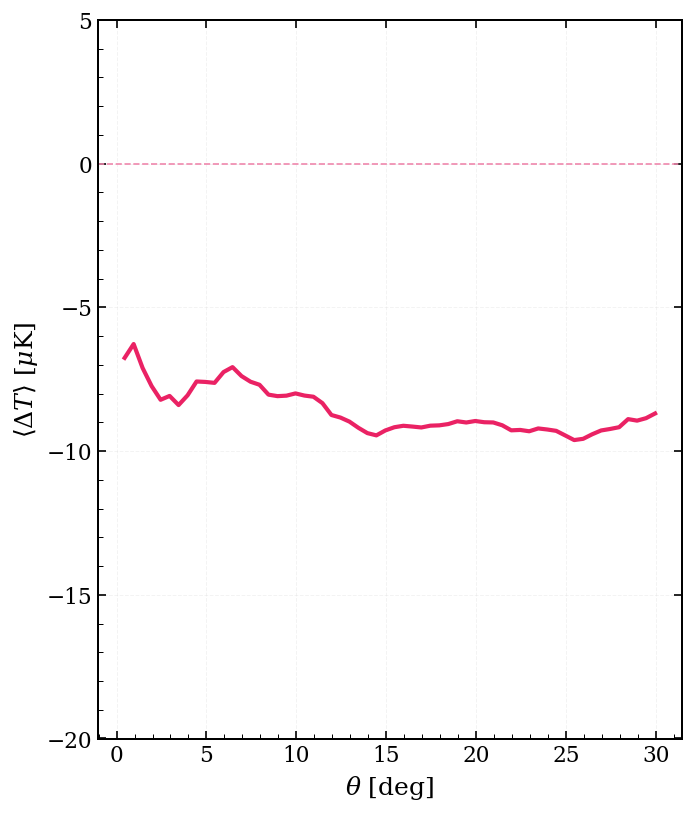

In [28]:
csv_individual = Path("/home/barbarantares/Documentos/SESSION/Perfiles_individuales_2MASS_Group_A_MC_00000.csv")
df_ind = pd.read_csv(csv_individual)

df_promedio = df_ind.groupby("radio_medio_deg",as_index=False).agg(perfil_promedio_uK=("perfil_uK","mean"))

plt.figure(figsize=(6,7))
plt.plot(df_promedio["radio_medio_deg"],df_promedio["perfil_promedio_uK"],lw=2.5,c='#EA2264')

plt.xlabel(r"$\theta$ [deg]",fontsize=15)
plt.ylabel(r"$\langle \Delta T \rangle$ [$\mu$K]",fontsize=15)
plt.axhline(0,color="#EF88AD",lw=1,linestyle="--")
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.ylim(-20,5)
plt.tick_params(labelsize=13,top=True,right=True,direction="in")

plt.tight_layout()
plt.savefig("/home/barbarantares/Documentos/SESSION/promediosim.png", dpi=600, bbox_inches="tight")

plt.show()

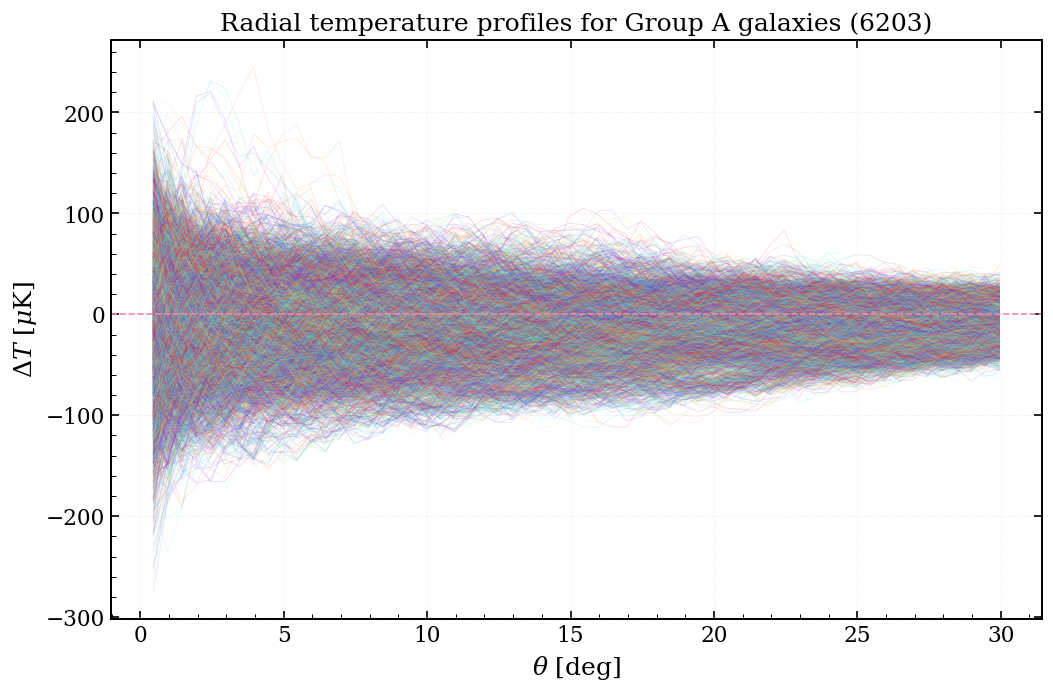

In [29]:
csv_individual = Path("/home/barbarantares/Documentos/SESSION/Perfiles_individuales_2MASS_Group_A_MC_00000.csv")
df_ind = pd.read_csv(csv_individual)

plt.figure(figsize=(9,6))

for galaxy_id,df_gal in df_ind.groupby("galaxy_id"):
    plt.plot(df_gal["radio_medio_deg"],df_gal["perfil_uK"],lw=0.5,alpha=0.15)

plt.xlabel(r"$\theta$ [deg]",fontsize=15)
plt.ylabel(r"$\Delta T$ [$\mu$K]",fontsize=15)
plt.title("Radial temperature profiles for Group A galaxies (6203)",fontsize=15)
plt.axhline(0,color="#EF88AD",lw=1,linestyle="--")
plt.tick_params(labelsize=13,top=True,right=True,direction="in")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/home/barbarantares/Documentos/SESSION/individualessim.png", dpi=600, bbox_inches="tight")

plt.show()

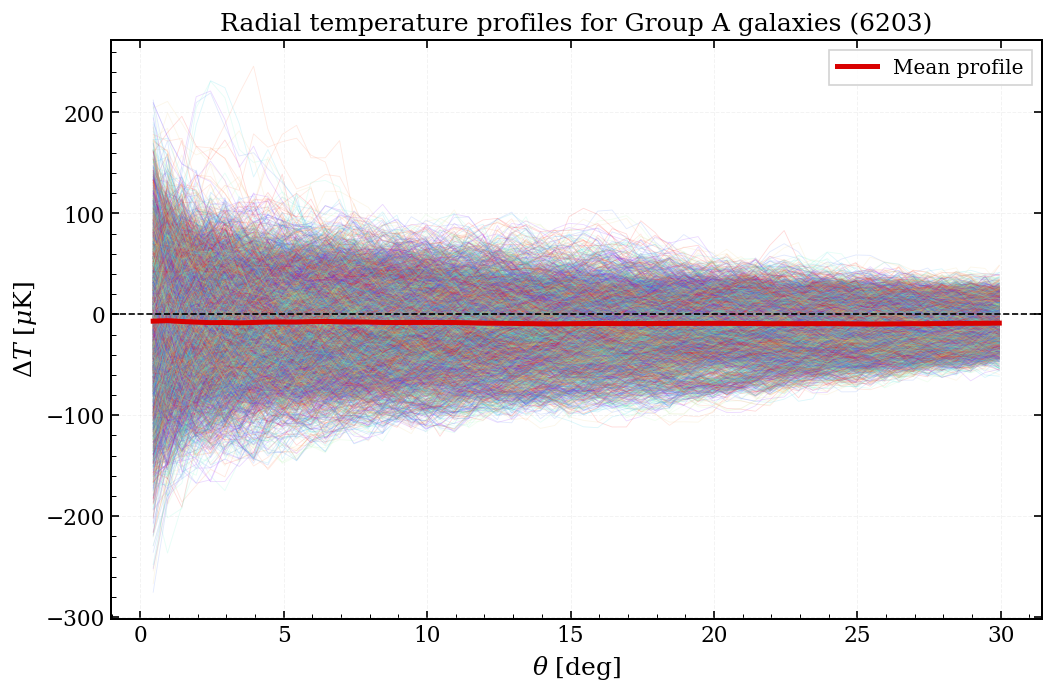

In [30]:
csv_individual = Path("/home/barbarantares/Documentos/SESSION/Perfiles_individuales_2MASS_Group_A_MC_00000.csv")
df_ind = pd.read_csv(csv_individual)

df_promedio = df_ind.groupby("radio_medio_deg",as_index=False).agg(perfil_promedio_uK=("perfil_uK","mean"))

plt.figure(figsize=(9,6))

for galaxy_id,df_gal in df_ind.groupby("galaxy_id"):
    plt.plot(df_gal["radio_medio_deg"],df_gal["perfil_uK"],lw=0.5,alpha=0.15)

plt.plot(df_promedio["radio_medio_deg"],df_promedio["perfil_promedio_uK"],lw=3,c="#D90000",label="Mean profile",zorder=10)

plt.xlabel(r"$\theta$ [deg]",fontsize=15)
plt.ylabel(r"$\Delta T$ [$\mu$K]",fontsize=15)
plt.title("Radial temperature profiles for Group A galaxies (6203)",fontsize=15)
plt.axhline(0,color="black",lw=1,linestyle="--")
plt.tick_params(labelsize=13,top=True,right=True,direction="in")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("/home/barbarantares/Documentos/SESSION/radial+promedio.png", dpi=600, bbox_inches="tight")

plt.show()

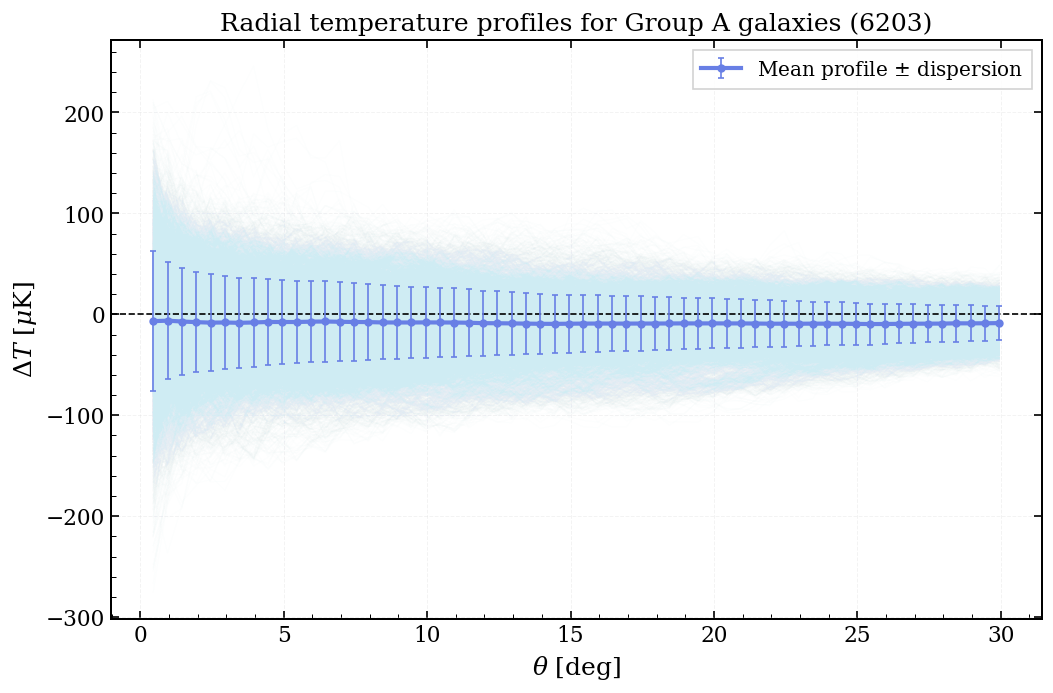

In [31]:
csv_individual = Path("/home/barbarantares/Documentos/SESSION/Perfiles_individuales_2MASS_Group_A_MC_00000.csv")
df_ind = pd.read_csv(csv_individual)

df_promedio = df_ind.groupby("radio_medio_deg",as_index=False).agg(
    perfil_promedio_uK=("perfil_uK","mean"),
    dispersion_uK=("perfil_uK","std")
)

plt.figure(figsize=(9,6))

for galaxy_id,df_gal in df_ind.groupby("galaxy_id"):
    plt.plot(
        df_gal["radio_medio_deg"],
        df_gal["perfil_uK"],
        color="#CFECF3",
        lw=0.5,
        alpha=0.05
    )

plt.errorbar(
    df_promedio["radio_medio_deg"],
    df_promedio["perfil_promedio_uK"],
    yerr=df_promedio["dispersion_uK"],
    color="#687FE5",
    marker="o",
    markersize=4,
    lw=2.5,
    elinewidth=1,
    capsize=2,
    label=r"Mean profile $\pm$ dispersion",
    zorder=10
)

plt.xlabel(r"$\theta$ [deg]",fontsize=15)
plt.ylabel(r"$\Delta T$ [$\mu$K]",fontsize=15)
plt.title("Radial temperature profiles for Group A galaxies (6203)",fontsize=15)

plt.axhline(0,color="black",lw=1,linestyle="--")
plt.tick_params(labelsize=13,top=True,right=True,direction="in")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("/home/barbarantares/Documentos/SESSION/dispersion.png", dpi=600, bbox_inches="tight")

plt.show()

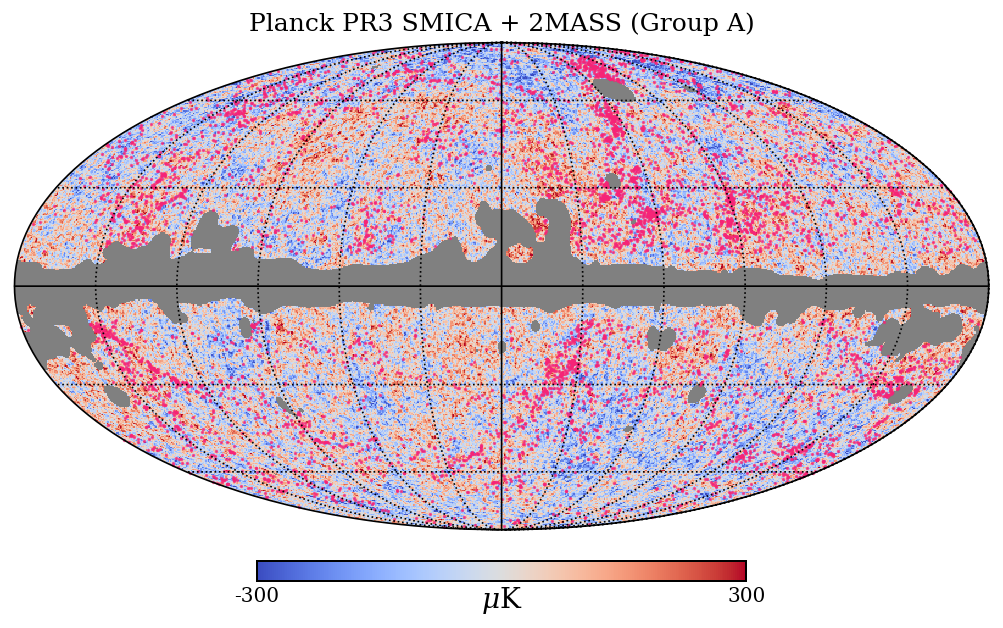

In [37]:

csv_individual = Path("/home/barbarantares/Documentos/SESSION/Perfiles_individuales_2MASS_Group_A_MC_00000.csv")
df_ind = pd.read_csv(csv_individual)

df_galaxias = df_ind.drop_duplicates(subset="galaxy_id")

pix_galaxias = df_galaxias["pixel_galaxia"].astype(int).to_numpy()

theta_gal,phi_gal = hp.pix2ang(NSIDE,pix_galaxias)


hp.mollview(mapa_smica, title="Planck PR3 SMICA + 2MASS (Group A)", cmap="coolwarm", unit=r"$\mu$K", min=-300, max=300)
hp.graticule()
hp.projscatter(theta_gal, phi_gal, s=4, c="#F62477", alpha=0.7, marker=".")
plt.savefig("/home/barbarantares/Documentos/SESSION/groupA_planck.png", dpi=600, bbox_inches="tight")
plt.show()